## Import Needed libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import yfinance as yf 
from statsmodels.tsa.stattools import adfuller
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
import os



## Downloading Dataset

In [2]:
df = yf.download("^GSPC", start="2000-01-01" , auto_adjust=False) 

[*********************100%***********************]  1 of 1 completed


## Preprocessing

In [4]:
df = df.reset_index()
df["day"] = df["Date"].dt.day
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["day_sin"] = np.sin(2 * np.pi * df["day"] / 31)
df["day_cos"] = np.cos(2 * np.pi * df["day"] / 31)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

scaler_year = MinMaxScaler()
df["year_norm"] = scaler_year.fit_transform(df[["year"]])

## Plotting the dataset

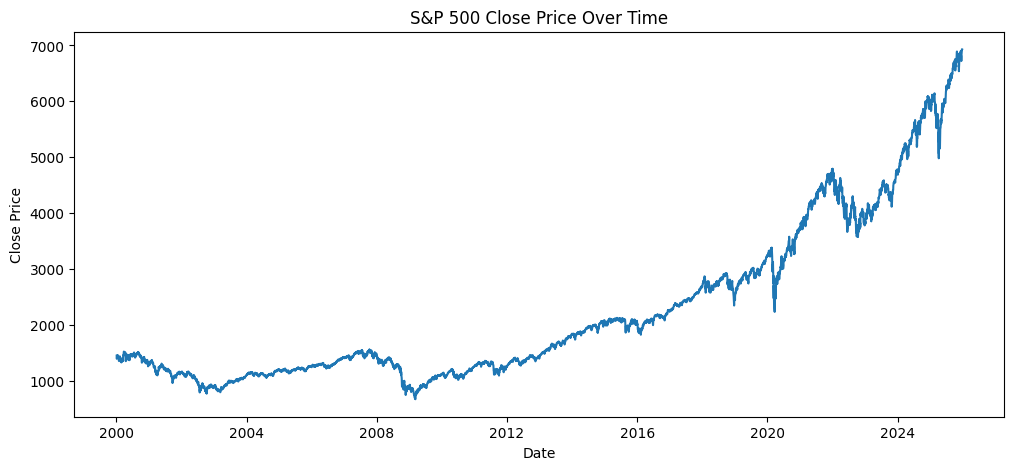

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"])
plt.title("S&P 500 Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()


## Autocorrelation Analysis of the Close Price Time Series


<Figure size 1200x400 with 0 Axes>

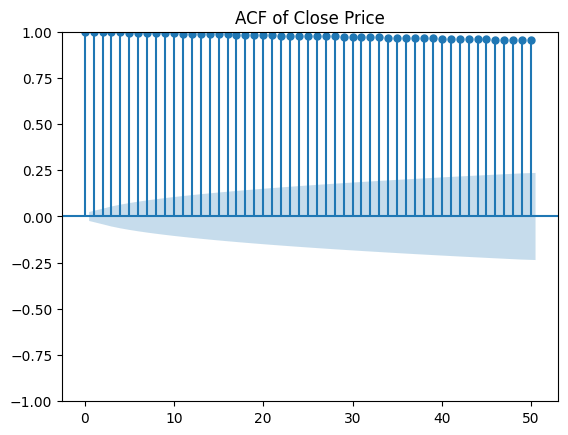

<Figure size 1200x400 with 0 Axes>

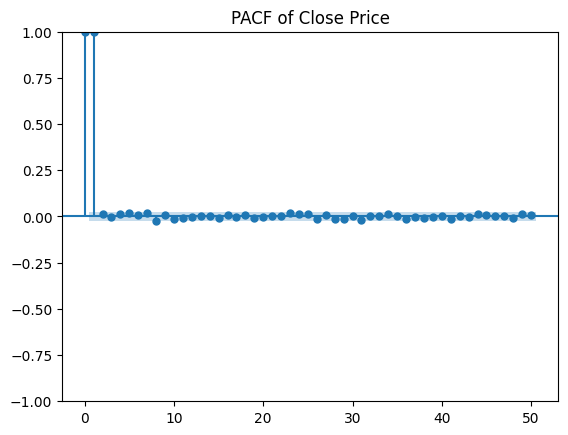

In [8]:
close_series = df["Close"]

plt.figure(figsize=(12,4))
plot_acf(close_series, lags=50)
plt.title("ACF of Close Price")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(close_series, lags=50, method="ywm")
plt.title("PACF of Close Price")
plt.show()


## Autocorrelation Analysis of the Close Price Time Series after differentiate


<Figure size 1200x400 with 0 Axes>

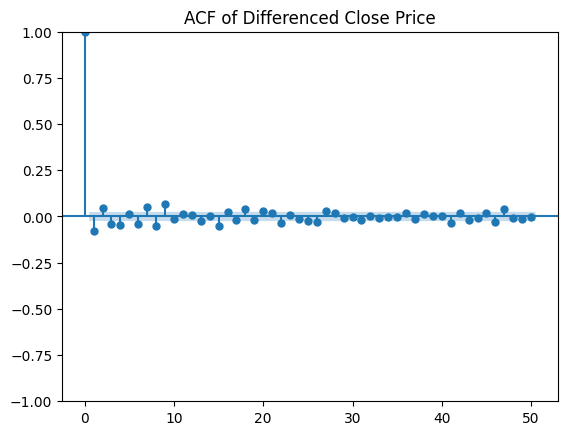

<Figure size 1200x400 with 0 Axes>

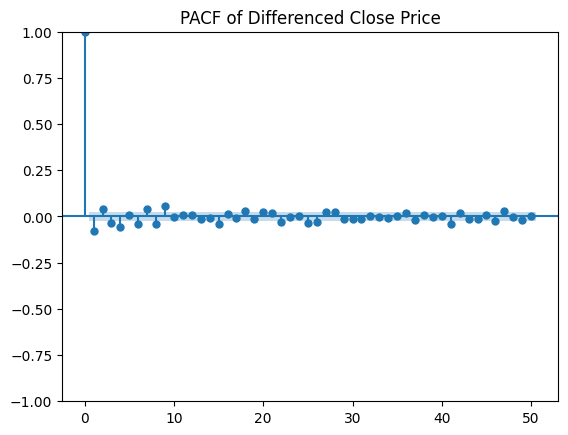

In [10]:
diff_close = close_series.diff().dropna()
plt.figure(figsize=(12,4))
plot_acf(diff_close, lags=50)
plt.title("ACF of Differenced Close Price")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(diff_close, lags=50, method="ywm")
plt.title("PACF of Differenced Close Price")
plt.show()


## Stationarity Test Using ADF


In [11]:
result = adfuller(close_series.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 2.981859838013169
p-value: 1.0


## Stationarity Test After First-Order Differencing


In [12]:
result_diff = adfuller(diff_close)
print("ADF Statistic (diff):", result_diff[0])
print("p-value (diff):", result_diff[1])


ADF Statistic (diff): -15.5470834544971
p-value (diff): 2.123128059271025e-28


## Feature and Target Selection for Time Series Modeling


In [13]:
df = df.sort_values("Date").reset_index(drop=True)

df["Close_diff"] = df["Close"].diff()
df = df.dropna().reset_index(drop=True)

feature_cols = [
    "Close_diff",
    "Volume",
    "day_sin", "day_cos",
    "month_sin", "month_cos",
    "year_norm"
]

target_col = "Close_diff"
data = df[feature_cols].values
target = df[target_col].values


## Sliding Window Construction for Sequence-to-Sequence Forecasting


In [15]:
INPUT_WINDOW = 20 
OUTPUT_WINDOW = 1 

def create_windows(X, y, input_window, output_window):
    X_windows = []
    y_windows = []

    for i in range(len(X) - input_window - output_window + 1):
        X_windows.append(X[i:i+input_window])
        y_windows.append(y[i+input_window:i+input_window+output_window])

    return np.array(X_windows), np.array(y_windows)


X_all, y_all = create_windows(
    data, target,
    INPUT_WINDOW,
    OUTPUT_WINDOW
)

## Train, Validation, and Test Split Based on Time Index


In [17]:
dates = df["Date"].iloc[INPUT_WINDOW + OUTPUT_WINDOW - 1:].reset_index(drop=True)
test_mask = dates >= "2024-01-01"

X_test = X_all[test_mask.values]
y_test = y_all[test_mask.values]

X_remain = X_all[~test_mask.values]
y_remain = y_all[~test_mask.values]

train_size = int(0.7 * len(X_remain))

X_train = X_remain[:train_size]
y_train = y_remain[:train_size]

X_val = X_remain[train_size:]
y_val = y_remain[train_size:]


## Feature and Target Scaling Using Standardization


In [20]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()


X_train_scaled = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
X_val_scaled   = scaler_X.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test_scaled  = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)


StandardScaler()

## Distribution of Input Feature in the Training Set


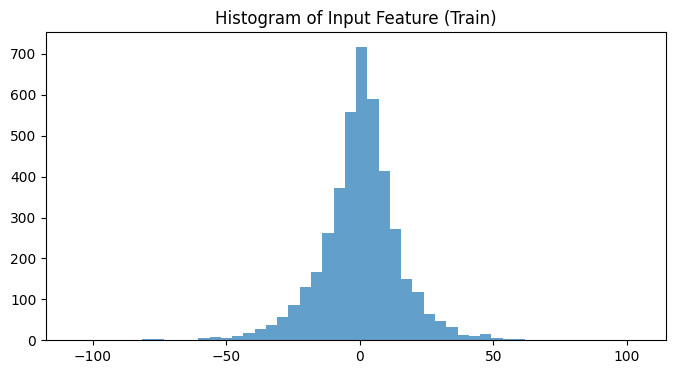

In [22]:
plt.figure(figsize=(8,4))
plt.hist(X_train[:,0,0], bins=50, alpha=0.7)
plt.title("Histogram of Input Feature (Train)")
plt.show()


## Distribution of Target Values Across Train, Validation, and Test Sets


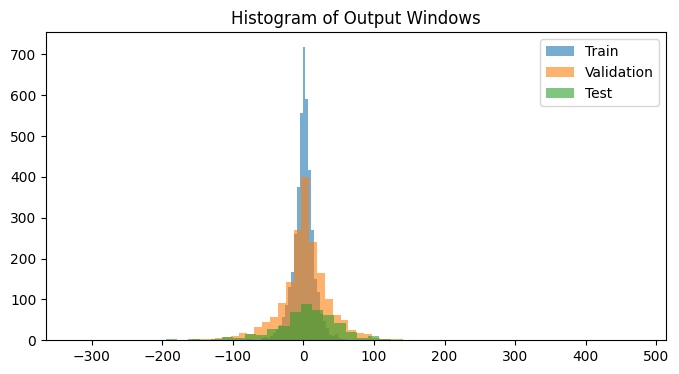

In [23]:
plt.figure(figsize=(8,4))
plt.hist(y_train.flatten(), bins=50, alpha=0.6, label="Train")
plt.hist(y_val.flatten(), bins=50, alpha=0.6, label="Validation")
plt.hist(y_test.flatten(), bins=50, alpha=0.6, label="Test")
plt.legend()
plt.title("Histogram of Output Windows")
plt.show()


# BaseLine

## Download and Preprocessing Data

In [ ]:
df = yf.download("^GSPC", start="2000-01-01", auto_adjust=False)
df = df[['Open','High','Low','Close']].dropna()

# add day and month features
df['Day'] = df.index.day
df['Month'] = df.index.month

# sine/cosine for day and month
df['Day_sin'] = np.sin(2 * np.pi * df['Day']/31)
df['Day_cos'] = np.cos(2 * np.pi * df['Day']/31)
df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)

# split test set for 2024-2025
test_mask = (df.index >= '2024-01-01') & (df.index <= '2025-12-31')
train_val_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

# create X and y sequences
INPUT_FEATURES = ['Open','High','Low','Close','Day_sin','Day_cos','Month_sin','Month_cos']
OUTPUT_FEATURES = ['Open','High','Low','Close']
WINDOW = 20

def create_sequences(data, input_features, output_features, window):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[input_features].iloc[i:i+window].values)
        y.append(data[output_features].iloc[i+window].values)
    return np.array(X), np.array(y)

X_trainval, y_trainval = create_sequences(train_val_df, INPUT_FEATURES, OUTPUT_FEATURES, WINDOW)
X_test, y_test = create_sequences(test_df, INPUT_FEATURES, OUTPUT_FEATURES, WINDOW)

# standard scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_trainval = scaler_X.fit_transform(X_trainval.reshape(-1, X_trainval.shape[-1])).reshape(X_trainval.shape)
y_trainval = scaler_y.fit_transform(y_trainval)

X_test = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_test = scaler_y.transform(y_test)

# train/validation split
split = int(0.8*len(X_trainval))
X_train, X_val = X_trainval[:split], X_trainval[split:]
y_train, y_val = y_trainval[:split], y_trainval[split:]

# create PyTorch datasets and dataloaders
train_dataset = TensorDataset(torch.tensor(X_train,dtype=torch.float32),
                              torch.tensor(y_train,dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val,dtype=torch.float32),
                            torch.tensor(y_val,dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test,dtype=torch.float32),
                             torch.tensor(y_test,dtype=torch.float32))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## Define a Simple MLP Model for Time Series Forecasting

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, output_dim=4, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        
        self.dropout = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

model = MLP(input_dim=WINDOW*len(INPUT_FEATURES))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

## Train MLP Model and Evaluate on Test Set


[*********************100%***********************]  1 of 1 completed


Epoch [10/100], Train Loss: 0.0039, Val Loss: 0.0120
Epoch [20/100], Train Loss: 0.0028, Val Loss: 0.0127
Epoch [30/100], Train Loss: 0.0025, Val Loss: 0.0061
Epoch [40/100], Train Loss: 0.0023, Val Loss: 0.0062
Epoch [50/100], Train Loss: 0.0021, Val Loss: 0.0046
Epoch [60/100], Train Loss: 0.0019, Val Loss: 0.0060
Epoch [70/100], Train Loss: 0.0020, Val Loss: 0.0341
Epoch [80/100], Train Loss: 0.0017, Val Loss: 0.0045
Epoch [90/100], Train Loss: 0.0018, Val Loss: 0.0153
Epoch [100/100], Train Loss: 0.0017, Val Loss: 0.0062


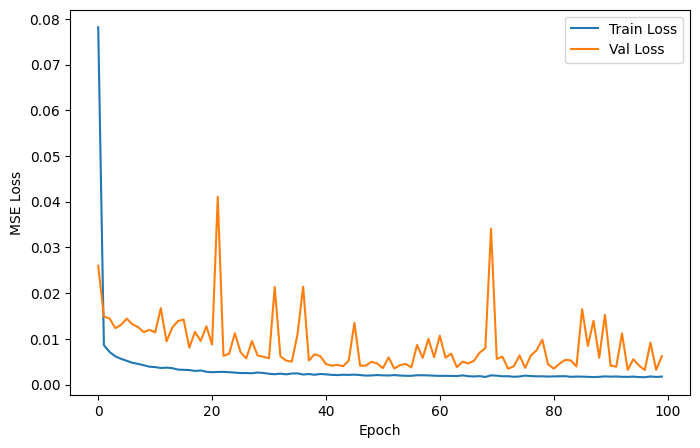

Test RMSE=220.6531, MAE=204.2193, R2=0.8341, MAPE=3.46%


In [72]:
EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(1,EPOCHS+1):
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()*X_batch.size(0)
    train_loss = running_loss/len(train_loader.dataset)
    
    model.eval()
    running_val = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            running_val += loss.item()*X_batch.size(0)
    val_loss = running_val/len(val_loader.dataset)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if epoch%10==0:
        print(f"Epoch [{epoch}/{EPOCHS}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')  # training loss
plt.plot(val_losses, label='Val Loss')      # validation loss
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# evaluate on test set
model.eval()
y_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        y_pred = model(X_batch)
        y_preds.append(y_pred)
y_preds = torch.cat(y_preds).numpy()
y_true = y_test

# inverse scale to original values
y_preds_orig = scaler_y.inverse_transform(y_preds)
y_true_orig = scaler_y.inverse_transform(y_true)

RMSE = np.sqrt(mean_squared_error(y_true_orig, y_preds_orig))
MAE = mean_absolute_error(y_true_orig, y_preds_orig)
R2 = r2_score(y_true_orig, y_preds_orig)
MAPE = np.mean(np.abs((y_true_orig - y_preds_orig)/y_true_orig))*100

print(f"Test RMSE={RMSE:.4f}, MAE={MAE:.4f}, R2={R2:.4f}, MAPE={MAPE:.2f}%")


## Plot Predicted vs True Prices for Each Feature


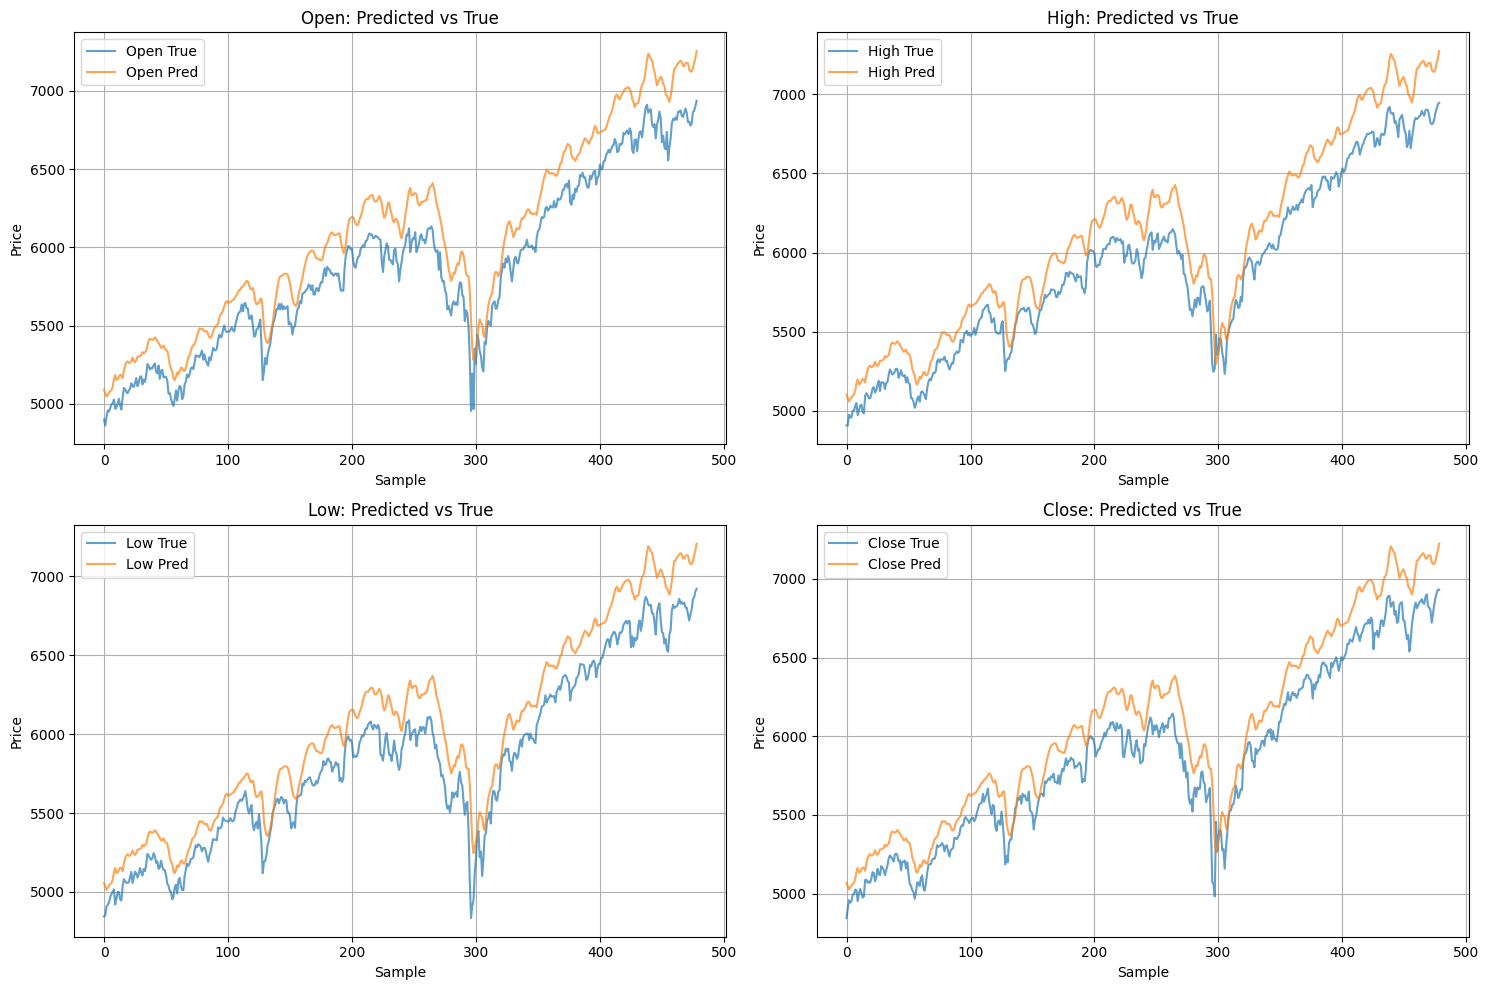

In [73]:
feature_names = ['Open','High','Low','Close']

plt.figure(figsize=(15,10))

for i, feature in enumerate(feature_names):
    plt.subplot(2,2,i+1)
    plt.plot(y_true_orig[:,i], label=f'{feature} True', alpha=0.7)
    plt.plot(y_preds_orig[:,i], label=f'{feature} Pred', alpha=0.7)
    plt.xlabel('Sample')
    plt.ylabel('Price')
    plt.title(f'{feature}: Predicted vs True')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


## Compare Actual vs Predicted Open and Close Prices


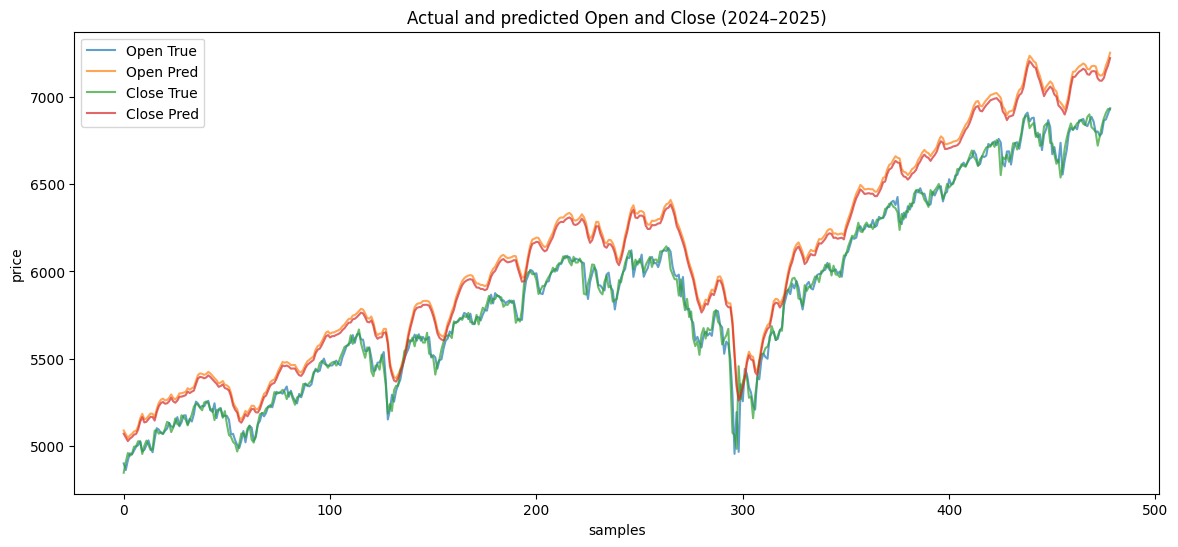

In [74]:
features = ['Open', 'Close']
indices = [0, 3] 

plt.figure(figsize=(14,6))
for i, idx in enumerate(indices):
    plt.plot(y_true_orig[:, idx], label=f'{features[i]} True', alpha=0.7)
    plt.plot(y_preds_orig[:, idx], label=f'{features[i]} Pred', alpha=0.7)
plt.xlabel('samples')
plt.ylabel('price')
plt.title('Actual and predicted Open and Close (2024–2025)')
plt.legend()
plt.show()


## Forecast Stock Prices for 2026–2027 Using Last Test Window


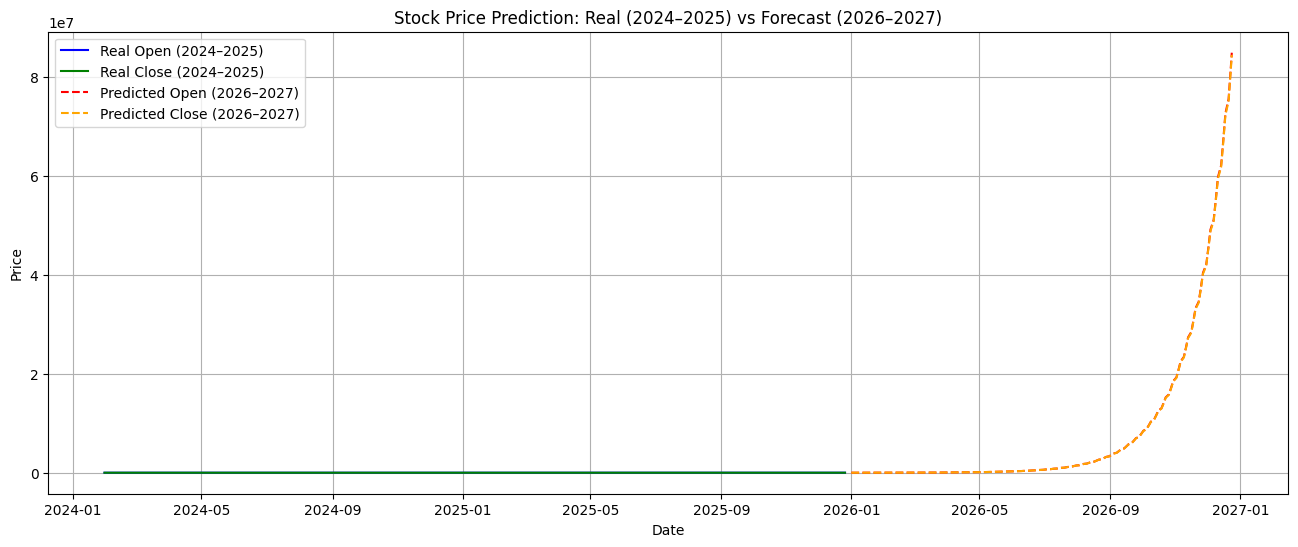

In [79]:
model.eval()
device = next(model.parameters()).device

# take the last window from test data
last_window = X_test[-1:]  # shape: (1, WINDOW, features)
last_window = torch.tensor(last_window, dtype=torch.float32).to(device)

future_steps = 256  # approx two trading years
future_preds = []

with torch.no_grad():
    for _ in range(future_steps):
        pred = model(last_window)  # predict next step
        future_preds.append(pred.cpu().numpy()[0])

        # shift the window and append new prediction
        last_window = torch.roll(last_window, shifts=-1, dims=1)
        last_window[0, -1, :4] = pred  # replace Open, High, Low, Close

future_preds = np.array(future_preds)

# inverse scale to original
future_preds_orig = scaler_y.inverse_transform(future_preds)

future_dates = pd.bdate_range(start="2026-01-01", periods=future_steps)

# actual data for comparison
real_dates = test_df.index[WINDOW:]
real_open = y_true_orig[:, 0]
real_close = y_true_orig[:, 3]

plt.figure(figsize=(16,6))

# plot actual
plt.plot(real_dates, real_open, label="Real Open (2024–2025)", color="blue")
plt.plot(real_dates, real_close, label="Real Close (2024–2025)", color="green")

# plot forecast
plt.plot(future_dates, future_preds_orig[:, 0],
         label="Predicted Open (2026–2027)",
         linestyle="--", color="red")
plt.plot(future_dates, future_preds_orig[:, 3],
         label="Predicted Close (2026–2027)",
         linestyle="--", color="orange")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Prediction: Real (2024–2025) vs Forecast (2026–2027)")
plt.legend()
plt.grid(True)
plt.show()


# CNN+LSTM Model

## Prepare Time Series Data for LSTM Forecasting


In [ ]:
df = yf.download("^GSPC", start="2000-01-01", auto_adjust=False)
df = df[['Open','High','Low','Close']].dropna()

# add day and month features
df['Day'] = df.index.day
df['Month'] = df.index.month

# encode cyclical features using sine/cosine
df['Day_sin'] = np.sin(2 * np.pi * df['Day']/31)
df['Day_cos'] = np.cos(2 * np.pi * df['Day']/31)
df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)

# split test set for 2024-2025
test_mask = (df.index >= '2024-01-01') & (df.index <= '2025-12-31')
train_val_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

# create input/output sequences
INPUT_FEATURES = ['Open','High','Low','Close','Day_sin','Day_cos','Month_sin','Month_cos']
OUTPUT_FEATURES = ['Open','High','Low','Close']
WINDOW = 30

def create_sequences(data, input_features, output_features, window):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[input_features].iloc[i:i+window].values)
        y.append(data[output_features].iloc[i+window].values)
    return np.array(X), np.array(y)

X_trainval, y_trainval = create_sequences(train_val_df, INPUT_FEATURES, OUTPUT_FEATURES, WINDOW)
X_test, y_test = create_sequences(test_df, INPUT_FEATURES, OUTPUT_FEATURES, WINDOW)

# standardize features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_trainval = scaler_X.fit_transform(X_trainval.reshape(-1, X_trainval.shape[-1])).reshape(X_trainval.shape)
y_trainval = scaler_y.fit_transform(y_trainval)

X_test = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_test = scaler_y.transform(y_test)

# split train/validation sets
split = int(0.8*len(X_trainval))
X_train, X_val = X_trainval[:split], X_trainval[split:]
y_train, y_val = y_trainval[:split], y_trainval[split:]

# create PyTorch datasets and dataloaders
train_dataset = TensorDataset(torch.tensor(X_train,dtype=torch.float32),
                              torch.tensor(y_train,dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val,dtype=torch.float32),
                            torch.tensor(y_val,dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test,dtype=torch.float32),
                             torch.tensor(y_test,dtype=torch.float32))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # shuffled for training
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## Define CNN-LSTM Model for Time Series Forecasting


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)  # check if GPU is available

class CNN_LSTM(nn.Module):
    def __init__(self, input_features, conv_channels=64, lstm_hidden=64):
        super().__init__()

        # 1D convolution layer
        self.conv1 = nn.Conv1d(
            in_channels=input_features,
            out_channels=conv_channels,
            kernel_size=7,
            padding=1
        )
        self.relu = nn.ReLU()

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=lstm_hidden,
            num_layers=1,
            batch_first=True
        )

        # Fully connected layers
        self.fc1 = nn.Linear(lstm_hidden, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        # x: (batch, time, features)

        # Conv1D expects (batch, features, time)
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))

        # back to (batch, time, channels)
        x = x.permute(0, 2, 1)

        # LSTM
        out, _ = self.lstm(x)

        # take last time step
        h_last = out[:, -1, :]

        # Fully connected
        x = self.relu(self.fc1(h_last))
        x = self.fc2(x)

        return x

best_val_loss = float('inf')  # keep track of best validation loss
BEST_MODEL_PATH = "best_cnn_lstm_model.pt"

lr = 0.0002
model = CNN_LSTM(input_features=len(INPUT_FEATURES)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss = nn.MSELoss()  # mean squared error for regression
criterion = nn.MSELoss()
summary(model , input_size=(64,30,8))


Using device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN_LSTM                                 [64, 4]                   --
├─Conv1d: 1-1                            [64, 64, 26]              3,648
├─ReLU: 1-2                              [64, 64, 26]              --
├─LSTM: 1-3                              [64, 26, 64]              33,280
├─Linear: 1-4                            [64, 128]                 8,320
├─ReLU: 1-5                              [64, 128]                 --
├─Linear: 1-6                            [64, 4]                   516
Total params: 45,764
Trainable params: 45,764
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 62.01
Input size (MB): 0.06
Forward/backward pass size (MB): 1.77
Params size (MB): 0.18
Estimated Total Size (MB): 2.02

## Train CNN-LSTM Model, Evaluate, and Plot Results


[*********************100%***********************]  1 of 1 completed


Using device: cuda
Epoch [10/300] | Train Loss: 0.000704 | Val Loss: 0.431537
Epoch [20/300] | Train Loss: 0.000585 | Val Loss: 0.368473
Epoch [30/300] | Train Loss: 0.000492 | Val Loss: 0.293676
Epoch [40/300] | Train Loss: 0.000428 | Val Loss: 0.232107
Epoch [50/300] | Train Loss: 0.000396 | Val Loss: 0.195453
Epoch [60/300] | Train Loss: 0.000387 | Val Loss: 0.159466
Epoch [70/300] | Train Loss: 0.000299 | Val Loss: 0.134342
Epoch [80/300] | Train Loss: 0.000266 | Val Loss: 0.106705
Epoch [90/300] | Train Loss: 0.000253 | Val Loss: 0.091039
Epoch [100/300] | Train Loss: 0.000237 | Val Loss: 0.077511
Epoch [110/300] | Train Loss: 0.000232 | Val Loss: 0.075907
Epoch [120/300] | Train Loss: 0.000218 | Val Loss: 0.063179
Epoch [130/300] | Train Loss: 0.000188 | Val Loss: 0.057995
Epoch [140/300] | Train Loss: 0.000188 | Val Loss: 0.046077
Epoch [150/300] | Train Loss: 0.000173 | Val Loss: 0.050683
Epoch [160/300] | Train Loss: 0.000166 | Val Loss: 0.033769
Epoch [170/300] | Train Loss: 

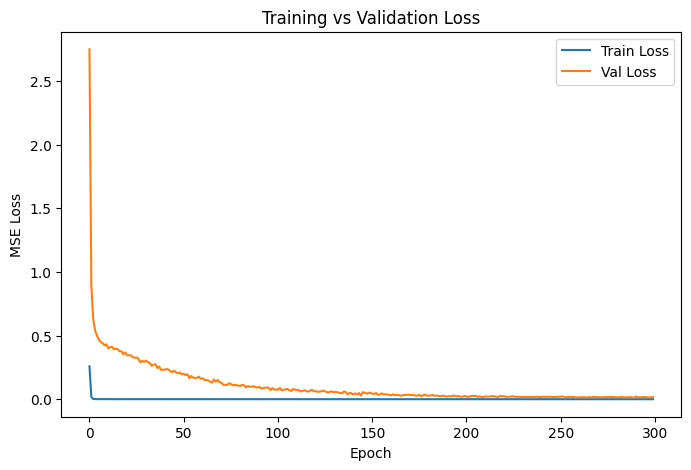

Test RMSE=1063.8164, MAE=983.3813, R2=-3.0185, MAPE=16.30%


In [67]:
EPOCHS = 300
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # validation step
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            running_val += loss.item() * X_batch.size(0)

    val_loss = running_val / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    if epoch % 10 == 0:
        print(f"Epoch [{epoch}/{EPOCHS}] | "
              f"Train Loss: {train_loss:.6f} | "
              f"Val Loss: {val_loss:.6f}")

# plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')  # training loss
plt.plot(val_losses, label='Val Loss')      # validation loss
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# evaluate on test set
model.eval()
y_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)
        y_preds.append(y_pred)

y_preds = torch.cat(y_preds)
y_preds = y_preds.cpu().numpy()
y_true = y_test

# inverse scale to original prices
y_preds_orig = scaler_y.inverse_transform(y_preds)
y_true_orig = scaler_y.inverse_transform(y_true)

# calculate metrics
RMSE = np.sqrt(mean_squared_error(y_true_orig, y_preds_orig))
MAE = mean_absolute_error(y_true_orig, y_preds_orig)
R2 = r2_score(y_true_orig, y_preds_orig)
MAPE = np.mean(np.abs((y_true_orig - y_preds_orig)/y_true_orig))*100

print(f"Test RMSE={RMSE:.4f}, MAE={MAE:.4f}, R2={R2:.4f}, MAPE={MAPE:.2f}%")

# plot predicted vs true for all 4 features
feature_names = ['Open','High','Low','Close']
plt.figure(figsize=(15,10))
for i, feature in enumerate(feature_names):
    plt.subplot(2,2,i+1)
    plt.plot(y_true_orig[:,i], label=f'{feature} True', alpha=0.7)
    plt.plot(y_preds_orig[:,i], label=f'{feature} Pred', alpha=0.7)
    plt.xlabel('Sample')
    plt.ylabel('Price')
    plt.title(f'{feature}: Predicted vs True')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()


## Plot Predicted vs Actual Open and Close Prices


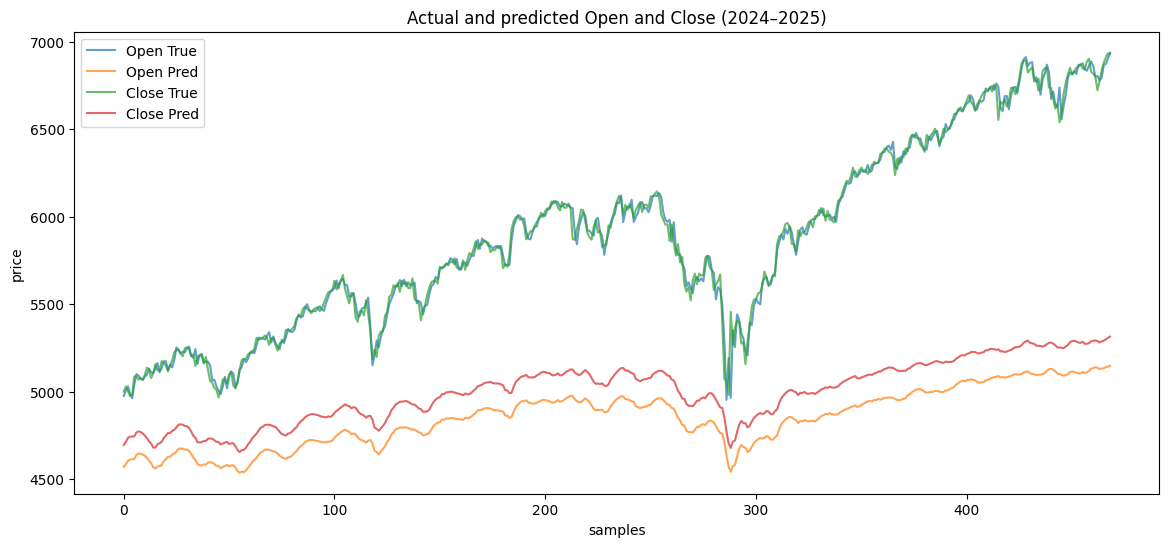

In [68]:
# select Open and Close features
features = ['Open', 'Close']
indices = [0, 3]  # Open=0, Close=3 in 4-dim output

plt.figure(figsize=(14,6))
for i, idx in enumerate(indices):
    plt.plot(y_true_orig[:, idx], label=f'{features[i]} True', alpha=0.7)  # actual prices
    plt.plot(y_preds_orig[:, idx], label=f'{features[i]} Pred', alpha=0.7)  # predicted prices
plt.xlabel('samples')
plt.ylabel('price')
plt.title('Actual and predicted Open and Close (2024–2025)')
plt.legend()
plt.show()


## Loading the best model

In [80]:
model = CNN_LSTM(input_features=len(INPUT_FEATURES))
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()
print(f"Best Validation Loss Loaded: {best_val_loss:.6f}")

Best Validation Loss Loaded: 0.012834


## Evaluate Model on Test Set and Plot Predictions for All Features


Test RMSE=1035.0864, MAE=950.8006, R2=-2.6550, MAPE=15.77%


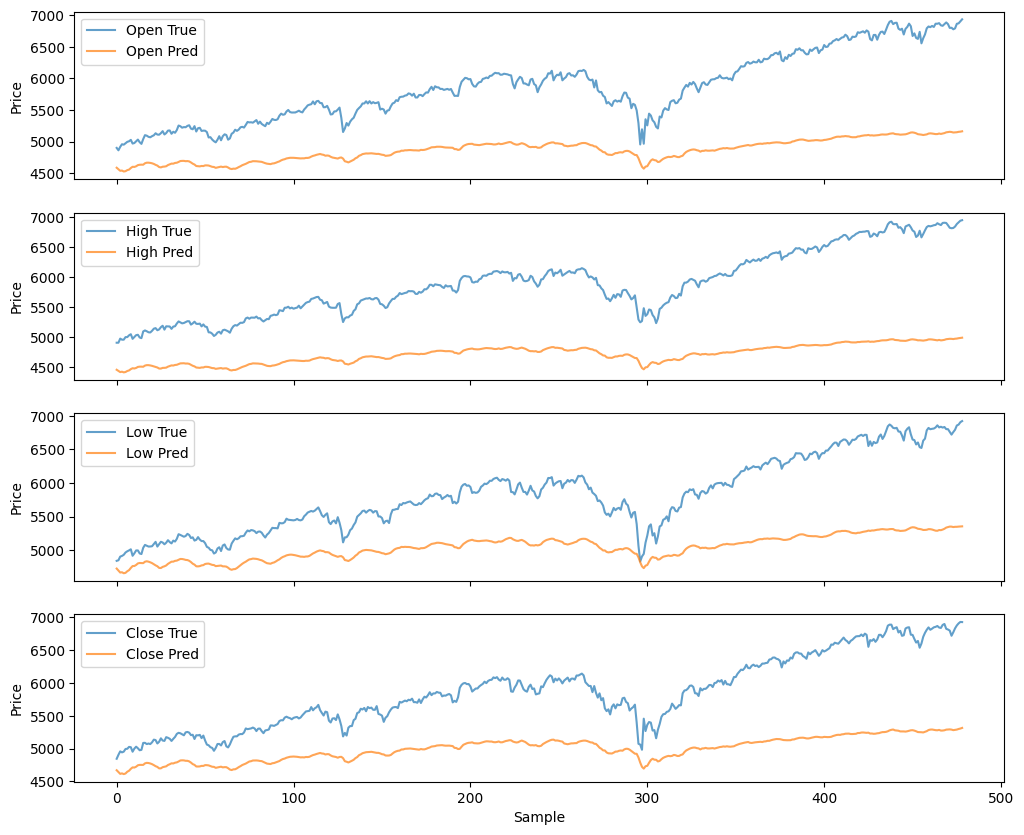

In [81]:
y_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        y_pred = model(X_batch)
        y_preds.append(y_pred)

y_preds = torch.cat(y_preds).numpy()
y_true = y_test

# inverse scaling to original prices
y_preds_orig = scaler_y.inverse_transform(y_preds)
y_true_orig = scaler_y.inverse_transform(y_true)

# calculate metrics
RMSE = np.sqrt(mean_squared_error(y_true_orig, y_preds_orig))
MAE = mean_absolute_error(y_true_orig, y_preds_orig)
R2 = r2_score(y_true_orig, y_preds_orig)
MAPE = np.mean(np.abs((y_true_orig - y_preds_orig) / y_true_orig)) * 100

print(f"Test RMSE={RMSE:.4f}, MAE={MAE:.4f}, R2={R2:.4f}, MAPE={MAPE:.2f}%")

# plot predicted vs true prices for all features
fig, axs = plt.subplots(4,1,figsize=(12,10), sharex=True)
features = ['Open','High','Low','Close']
for i, ax in enumerate(axs):
    ax.plot(y_true_orig[:,i], label=f'{features[i]} True', alpha=0.7)  # actual
    ax.plot(y_preds_orig[:,i], label=f'{features[i]} Pred', alpha=0.7)  # predicted
    ax.set_ylabel('Price')
    ax.legend()
plt.xlabel('Sample')
plt.show()


## Forecast Future Stock Prices (2026–2027) Using Last Test Window


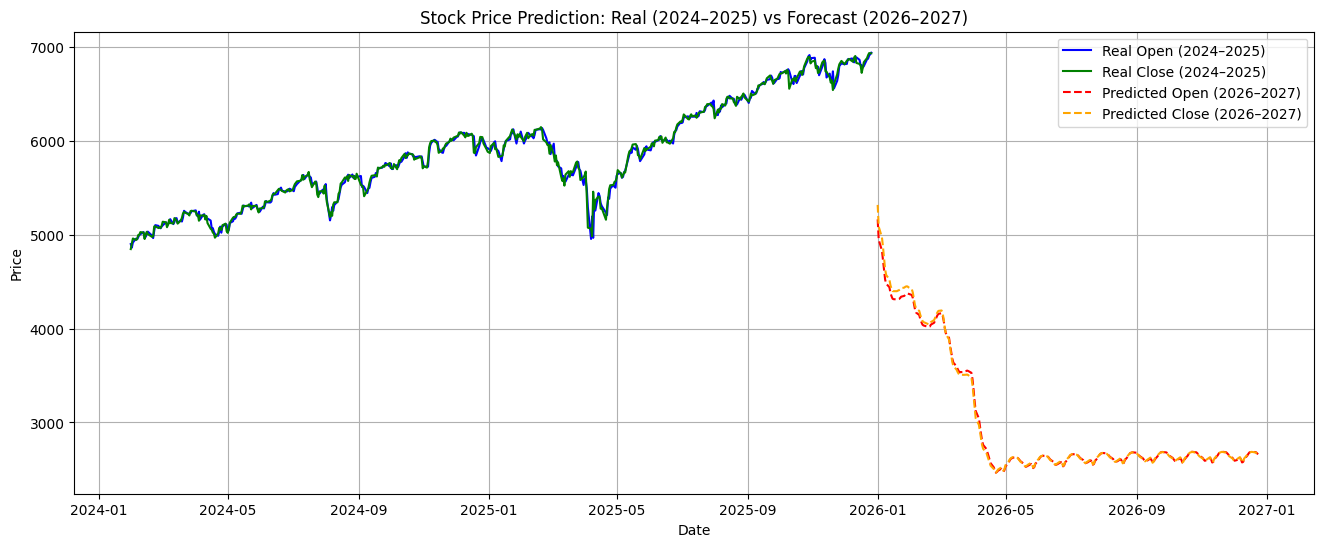

In [83]:
model.eval()
device = next(model.parameters()).device  # get device (CPU/GPU)

# take last window from test data
last_window = X_test[-1:]  # shape: (1, WINDOW, features)
last_window = torch.tensor(last_window, dtype=torch.float32).to(device)

future_steps = 256  # approx two years of trading
future_preds = []

with torch.no_grad():
    for _ in range(future_steps):
        pred = model(last_window)  # predict next step
        future_preds.append(pred.cpu().numpy()[0])

        # shift the window and append prediction
        last_window = torch.roll(last_window, shifts=-1, dims=1)
        last_window[0, -1, :4] = pred  # replace Open, High, Low, Close

future_preds = np.array(future_preds)

# inverse scaling to original values
future_preds_orig = scaler_y.inverse_transform(future_preds)

# generate future dates
future_dates = pd.bdate_range(start="2026-01-01", periods=future_steps)

# real data for 2024–2025
real_dates = test_df.index[WINDOW:]
real_open = y_true_orig[:, 0]
real_close = y_true_orig[:, 3]

plt.figure(figsize=(16,6))

# plot actual
plt.plot(real_dates, real_open, label="Real Open (2024–2025)", color="blue")
plt.plot(real_dates, real_close, label="Real Close (2024–2025)", color="green")

# plot forecast
plt.plot(future_dates, future_preds_orig[:, 0],
         label="Predicted Open (2026–2027)",
         linestyle="--", color="red")
plt.plot(future_dates, future_preds_orig[:, 3],
         label="Predicted Close (2026–2027)",
         linestyle="--", color="orange")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Prediction: Real (2024–2025) vs Forecast (2026–2027)")
plt.legend()
plt.grid(True)
plt.show()


# CNN+GRU Model

## Prepare S&P 500 Time Series Data for CNN-GRU Forecasting


In [ ]:
df = yf.download("^GSPC", start="2000-01-01", auto_adjust=False)
df = df[['Open','High','Low','Close']].dropna()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)  # check if GPU is available

# add day and month features
df['Day'] = df.index.day
df['Month'] = df.index.month

# encode cyclical features using sine/cosine
df['Day_sin'] = np.sin(2 * np.pi * df['Day']/31)
df['Day_cos'] = np.cos(2 * np.pi * df['Day']/31)
df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)

# split test set for 2024–2025
test_mask = (df.index >= '2024-01-01') & (df.index <= '2025-12-31')
train_val_df = df.loc[~test_mask].copy()
test_df = df.loc[test_mask].copy()

# create input/output sequences
INPUT_FEATURES = ['Open','High','Low','Close','Day_sin','Day_cos','Month_sin','Month_cos']
OUTPUT_FEATURES = ['Open','High','Low','Close']
WINDOW = 30

def create_sequences(data, input_features, output_features, window):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[input_features].iloc[i:i+window].values)
        y.append(data[output_features].iloc[i+window].values)
    return np.array(X), np.array(y)

X_trainval, y_trainval = create_sequences(train_val_df, INPUT_FEATURES, OUTPUT_FEATURES, WINDOW)
X_test, y_test = create_sequences(test_df, INPUT_FEATURES, OUTPUT_FEATURES, WINDOW)

# standardize features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_trainval = scaler_X.fit_transform(X_trainval.reshape(-1, X_trainval.shape[-1])).reshape(X_trainval.shape)
y_trainval = scaler_y.fit_transform(y_trainval)

X_test = scaler_X.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)
y_test = scaler_y.transform(y_test)

# split train/validation sets
split = int(0.8*len(X_trainval))
X_train, X_val = X_trainval[:split], X_trainval[split:]
y_train, y_val = y_trainval[:split], y_trainval[split:]

# create PyTorch datasets and dataloaders
train_dataset = TensorDataset(torch.tensor(X_train,dtype=torch.float32),
                              torch.tensor(y_train,dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val,dtype=torch.float32),
                            torch.tensor(y_val,dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_test,dtype=torch.float32),
                             torch.tensor(y_test,dtype=torch.float32))

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # shuffled for training
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## Define CNN-GRU Model for Time Series Forecasting


In [ ]:
class CNN_GRU(nn.Module):
    def __init__(self, input_features, conv_channels=64, gru_hidden=128, gru_layers=5, fc1_units=128, dropout=0.2):
        super().__init__()

        # Conv1D layer
        self.conv1 = nn.Conv1d(input_features, conv_channels, kernel_size=7, padding=1)
        self.relu = nn.ReLU()

        # GRU layer
        self.gru = nn.GRU(input_size=conv_channels,
                          hidden_size=gru_hidden,
                          num_layers=gru_layers,
                          batch_first=True,
                          dropout=dropout)

        # Fully connected layers with residual connection
        self.fc1 = nn.Linear(gru_hidden + conv_channels, fc1_units)  # concat GRU + Conv features
        self.fc2 = nn.Linear(fc1_units, 4)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Conv1D expects (batch, features, time)
        x_conv = x.permute(0,2,1)
        x_conv = self.relu(self.conv1(x_conv))
        x_conv_t = x_conv.permute(0,2,1)  # back to (batch, time, channels)

        # GRU
        out, _ = self.gru(x_conv_t)
        h_last = out[:, -1, :]  # last time step

        # residual connection: concatenate mean of Conv features and GRU output
        x_res = torch.cat([h_last, x_conv_t.mean(dim=1)], dim=1)

        x = self.dropout(self.relu(self.fc1(x_res)))
        x = self.fc2(x)
        return x

best_val_loss1 = float('inf')  # track best validation loss
BEST_MODEL_PATH1 = "best_cnn_gru_model.pt"

lr = 0.0005
model1 = CNN_GRU(input_features=len(INPUT_FEATURES)).to(device)
optimizer = torch.optim.Adam(
    model1.parameters(),
    lr=lr,
    weight_decay=1e-4
)
criterion = nn.MSELoss()  # mean squared error for regression
summary(model1 , input_size=(64,30,8))


Layer (type:depth-idx)                   Output Shape              Param #
CNN_GRU                                  [64, 4]                   --
├─Conv1d: 1-1                            [64, 64, 26]              3,648
├─ReLU: 1-2                              [64, 64, 26]              --
├─GRU: 1-3                               [64, 26, 128]             470,784
├─Linear: 1-4                            [64, 128]                 24,704
├─ReLU: 1-5                              [64, 128]                 --
├─Dropout: 1-6                           [64, 128]                 --
├─Linear: 1-7                            [64, 4]                   516
Total params: 499,652
Trainable params: 499,652
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 791.07
Input size (MB): 0.06
Forward/backward pass size (MB): 2.62
Params size (MB): 2.00
Estimated Total Size (MB): 4.68

## Train CNN-GRU Model and Evaluate on Test Set


[*********************100%***********************]  1 of 1 completed


Using device: cuda
Epoch [10/100] | Train Loss: 0.004296 | Val Loss: 0.092818
Epoch [20/100] | Train Loss: 0.003435 | Val Loss: 0.033435
Epoch [30/100] | Train Loss: 0.003326 | Val Loss: 0.024254
Epoch [40/100] | Train Loss: 0.003068 | Val Loss: 0.022351
Epoch [50/100] | Train Loss: 0.003037 | Val Loss: 0.019951
Epoch [60/100] | Train Loss: 0.002841 | Val Loss: 0.027658
Epoch [70/100] | Train Loss: 0.002703 | Val Loss: 0.032490
Epoch [80/100] | Train Loss: 0.002674 | Val Loss: 0.023705
Epoch [90/100] | Train Loss: 0.002721 | Val Loss: 0.024201
Epoch [100/100] | Train Loss: 0.002870 | Val Loss: 0.028808


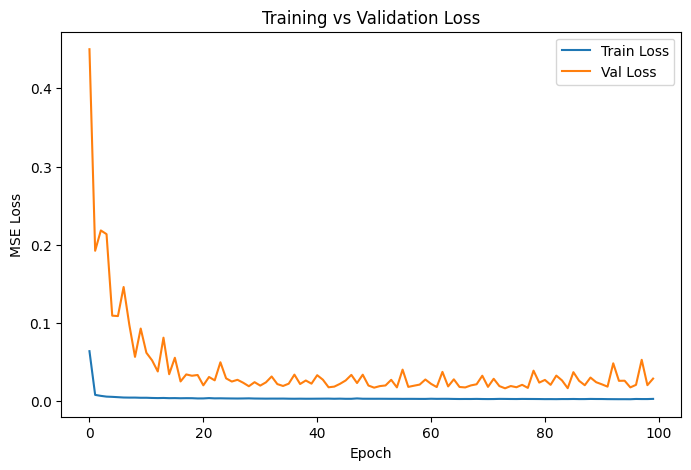

Test RMSE=264.9567, MAE=242.7724, R2=0.7511, MAPE=4.10%


In [84]:
EPOCHS = 100
train_losses1, val_losses1 = [], []

for epoch in range(1, EPOCHS + 1):
    model1.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model1(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()

        # gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model1.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    train_loss1 = running_loss / len(train_loader.dataset)

    # validation
    model1.eval()
    running_val = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model1(X_batch)
            loss = criterion(y_pred, y_batch)
            running_val += loss.item() * X_batch.size(0)

    val_loss1 = running_val / len(val_loader.dataset)

    train_losses1.append(train_loss1)
    val_losses1.append(val_loss1)

    # save best model
    if val_loss1 < best_val_loss1:
        best_val_loss1 = val_loss1
        torch.save(model1.state_dict(), BEST_MODEL_PATH1)

    if epoch % 10 == 0:
        print(f"Epoch [{epoch}/{EPOCHS}] | "
              f"Train Loss: {train_loss1:.6f} | "
              f"Val Loss: {val_loss1:.6f}")

# plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(train_losses1, label='Train Loss')
plt.plot(val_losses1, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# evaluate on test set
model1.eval()
y_preds1 = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_pred1 = model1(X_batch)
        y_preds1.append(y_pred1)

y_preds1 = torch.cat(y_preds1).cpu().numpy()
y_true = y_test

# inverse transform to original scale
y_preds_orig1 = scaler_y.inverse_transform(y_preds1)
y_true_orig1 = scaler_y.inverse_transform(y_true)

# compute metrics
RMSE1 = np.sqrt(mean_squared_error(y_true_orig1, y_preds_orig1))
MAE1 = mean_absolute_error(y_true_orig1, y_preds_orig1)
R21 = r2_score(y_true_orig1, y_preds_orig1)
MAPE1 = np.mean(np.abs((y_true_orig1 - y_preds_orig1)/y_true_orig1))*100

print(f"Test RMSE={RMSE1:.4f}, MAE={MAE1:.4f}, R2={R21:.4f}, MAPE={MAPE1:.2f}%")


## Loading the best model

In [85]:
model1.load_state_dict(torch.load(BEST_MODEL_PATH1))
model1.eval()

print(f"Best Validation Loss Loaded: {best_val_loss1:.6f}")


Best Validation Loss Loaded: 0.016407


## Evaluate CNN-GRU Predictions and Plot All Features


Test RMSE=141.6911, MAE=96.7789, R2=0.9289, MAPE=1.70%


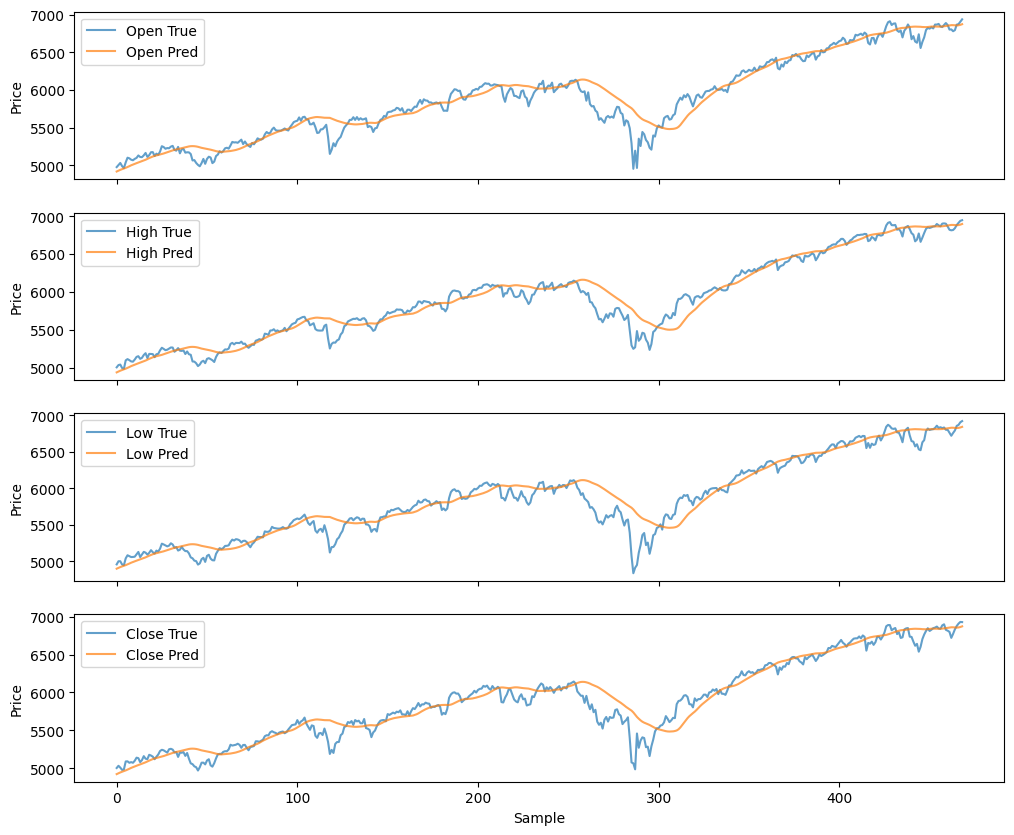

In [86]:
y_preds = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model1(X_batch)
        y_preds.append(y_pred)

# combine all batches and move to CPU
y_preds = torch.cat(y_preds).cpu().numpy()
y_true = y_test  # already numpy

# inverse transform to original scale
y_preds_orig = scaler_y.inverse_transform(y_preds)
y_true_orig = scaler_y.inverse_transform(y_true)

# compute metrics
RMSE = np.sqrt(mean_squared_error(y_true_orig, y_preds_orig))
MAE = mean_absolute_error(y_true_orig, y_preds_orig)
R2 = r2_score(y_true_orig, y_preds_orig)
MAPE = np.mean(np.abs((y_true_orig - y_preds_orig) / y_true_orig)) * 100

print(f"Test RMSE={RMSE:.4f}, MAE={MAE:.4f}, R2={R2:.4f}, MAPE={MAPE:.2f}%")

# plot predictions vs true values for all features
fig, axs = plt.subplots(4, 1, figsize=(12,10), sharex=True)
features = ['Open','High','Low','Close']
for i, ax in enumerate(axs):
    ax.plot(y_true_orig[:, i], label=f'{features[i]} True', alpha=0.7)
    ax.plot(y_preds_orig[:, i], label=f'{features[i]} Pred', alpha=0.7)
    ax.set_ylabel('Price')
    ax.legend()
plt.xlabel('Sample')
plt.show()


## Plot Predicted vs True Open and Close Prices


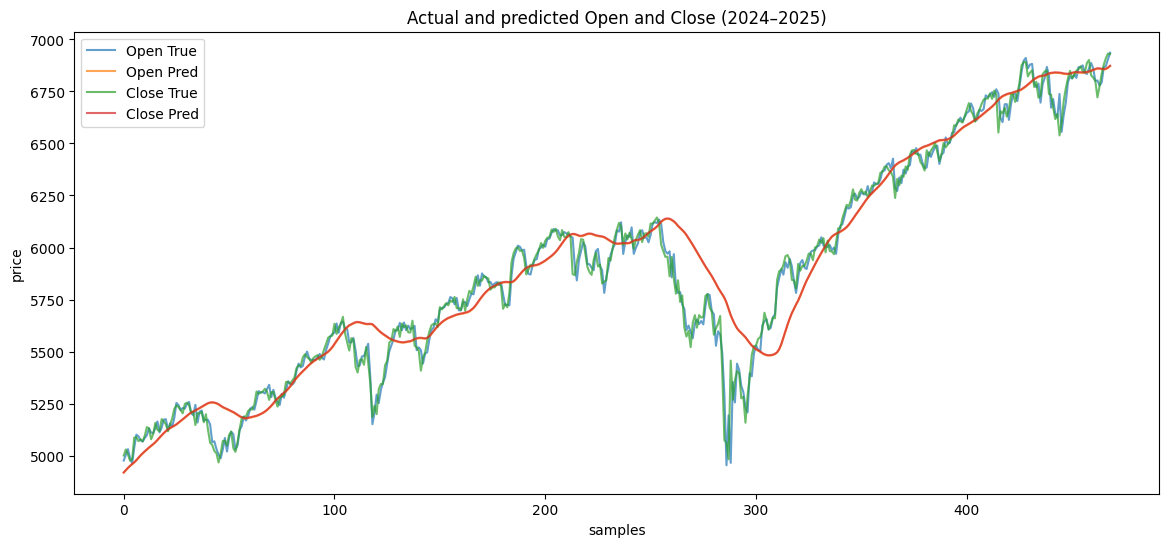

In [87]:
# select features Open and Close
features = ['Open', 'Close']
indices = [0, 3]  # positions in output array

plt.figure(figsize=(14,6))
for i, idx in enumerate(indices):
    plt.plot(y_true_orig[:, idx], label=f'{features[i]} True', alpha=0.7)
    plt.plot(y_preds_orig[:, idx], label=f'{features[i]} Pred', alpha=0.7)

plt.xlabel('Samples')
plt.ylabel('Price')
plt.title('Actual and Predicted Open and Close (2024–2025)')
plt.legend()
plt.show()


## Forecast Future Open and Close Prices (2026–2027)


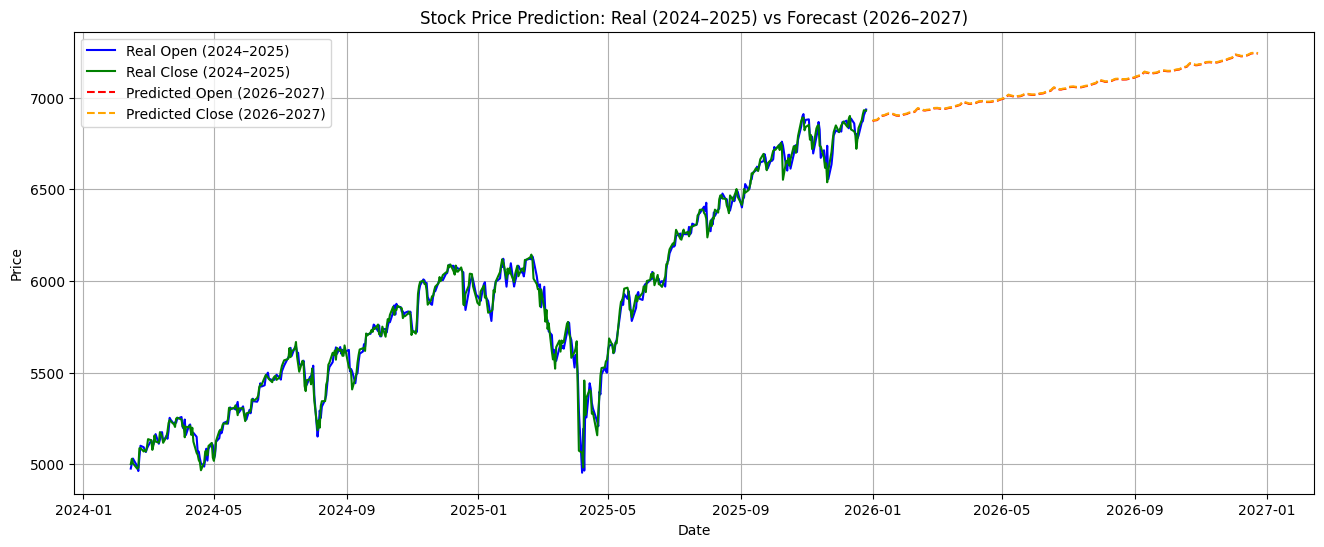

In [90]:
model1.eval()

device = next(model1.parameters()).device

# take last window from test data (end of 2025)
last_window = X_test[-1:]  # shape: (1, WINDOW, features)
last_window = torch.tensor(last_window, dtype=torch.float32).to(device)

future_steps = 256  # roughly two years of trading days
future_preds = []

with torch.no_grad():
    for _ in range(future_steps):
        pred = model1(last_window)  # predict next step
        future_preds.append(pred.cpu().numpy()[0])

        # shift window to include new prediction
        last_window = torch.roll(last_window, shifts=-1, dims=1)
        last_window[0, -1, :4] = pred  # update only Open, High, Low, Close

future_preds = np.array(future_preds)
future_preds_orig = scaler_y.inverse_transform(future_preds)

# create future dates
future_dates = pd.bdate_range(start="2026-01-01", periods=future_steps)

# actual data 2024–2025
real_dates = test_df.index[WINDOW:]
real_open = y_true_orig1[:, 0]
real_close = y_true_orig1[:, 3]

plt.figure(figsize=(16,6))

# plot real prices
plt.plot(real_dates, real_open, label="Real Open (2024–2025)", color="blue")
plt.plot(real_dates, real_close, label="Real Close (2024–2025)", color="green")

# plot future predictions
plt.plot(future_dates, future_preds_orig[:, 0],
         label="Predicted Open (2026–2027)",
         linestyle="--", color="red")
plt.plot(future_dates, future_preds_orig[:, 3],
         label="Predicted Close (2026–2027)",
         linestyle="--", color="orange")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Prediction: Real (2024–2025) vs Forecast (2026–2027)")
plt.legend()
plt.grid(True)
plt.show()


## Compate all models

In [5]:
import pandas as pd

data = {
    "Model": ["MLP", "CNN + LSTM", "CNN + GRU"],
    "Parameters": [18884, 45764, 499652],
    "RMSE": [220.6531, 1063.8164, 264.9567],
    "MAE": [204.2193, 983.3813, 242.7724],
    "R2": [0.8341, -3.0185, 0.7511],
    "MAPE (%)": [3.46, 16.30, 4.10]
}

df = pd.DataFrame(data)

print(df)




        Model  Parameters       RMSE       MAE      R2  MAPE (%)
0         MLP       18884   220.6531  204.2193  0.8341      3.46
1  CNN + LSTM       45764  1063.8164  983.3813 -3.0185     16.30
2   CNN + GRU      499652   264.9567  242.7724  0.7511      4.10
